In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


#loading the first dataset (books.csv)

books = pd.read_csv("Books.csv", encoding="latin-1")

books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-L']]

books = books.rename(columns={
    'ISBN': 'isbn',
    'Book-Title': 'title',
    'Book-Author': 'author',
    'Year-Of-Publication': 'year',
    'Publisher': 'publisher',
    'Image-URL-L': 'image_url'
})

books.head()

C:\Users\furez\AppData\Local\Temp\ipykernel_5092\567662935.py:9: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv", encoding="latin-1")


,isbn,title,author,year,publisher,image_url
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...


In [4]:
# loading the second dataset (users.csv)

users = pd.read_csv("Users.csv", encoding="latin-1")


users.rename(columns={'User-ID': 'user_id',
                       'Location': 'location', 
                       'Age': 'age'}, inplace=True)

users.head()

,user_id,location,age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
# now lets load the third dataset (ratings .csv)

ratings = pd.read_csv("Ratings.csv", encoding="latin-1")


ratings.rename(columns={'User-ID': 'user_id',
                       'ISBN': 'isbn',
                       'Book-Rating': 'rating'}, inplace=True)

ratings.head()


,user_id,isbn,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


### Rating table is the most important here for recommendations, as it shows us the ratings, now lets explore:
- Who is the most active user/ who is reading highest number of books?

In [6]:
ratings['user_id'].value_counts()

user_id
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
          ...  
276697        1
276706        1
276709        1
276721        1
276723        1
Name: count, Length: 105283, dtype: int64

## Insights
- users ID 11676 reads 13602 books (higest amount of books).

## Outliers in this data
- users who are reading only 1-2 books are ouliers in our dataset because we are only consideing those read at least 200 books.

In [7]:
X = ratings['user_id'].value_counts() > 200

X

user_id
11676      True
198711     True
153662     True
98391      True
35859      True
          ...  
276697    False
276706    False
276709    False
276721    False
276723    False
Name: count, Length: 105283, dtype: bool

## Those who read at least 200 books as compared to rest of the users:
- only 899 out of  105283 users read at least 200 books 


In [8]:
X[X].shape

(899,)

### The index number of those users who read at least 200 books

In [9]:
y = X[X].index
y

Index([ 11676, 198711, 153662,  98391,  35859, 212898, 278418,  76352, 110973,
       235105,
       ...
       260183,   9856,  28634,  44296,  59727,  73681, 155916, 188951, 268622,
       274808],
      dtype='int64', name='user_id', length=899)

In [10]:
# taking only those ratings which are given by users who have rated more than 200 books
ratings = ratings[ratings['user_id'].isin(y)]
ratings.head()

,user_id,isbn,rating
1456,277427,002542730X,10
1457,277427,0026217457,0
1458,277427,003008685X,8
1459,277427,0030615321,0
1460,277427,0060002050,0


### Mergeing the ratings and books together (both having isbn number)

In [11]:
ratings_with_books = ratings.merge(books, on = 'isbn')
ratings_with_books.head()

,user_id,isbn,rating,title,author,year,publisher,image_url
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...


### Which books has got what rating number (this feature is named as number_of_ratings)

In [12]:
number_of_ratings = ratings_with_books.groupby('title').count()['rating'].reset_index()
number_of_ratings.rename(columns={'rating': 'number_of_ratings'}, inplace=True)
number_of_ratings.head()

,title,number_of_ratings
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


### final_rating is the name of the df which has the rating numner for the books 

In [13]:
final_ratings = ratings_with_books.merge(number_of_ratings, on = 'title')
final_ratings.head()

# number of rating  column is added below , it shows us how many ratings each book has got

,user_id,isbn,rating,title,author,year,publisher,image_url,number_of_ratings
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,7
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,13


### Lets look at only those books which got at least more than 50 ratings / most rated books


In [14]:
final_ratings_50 = final_ratings[final_ratings['number_of_ratings']>=50]
final_ratings_50.head()

,user_id,isbn,rating,title,author,year,publisher,image_url,number_of_ratings
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,133
15,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,108
24,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,79


### Insights
- I filtered the dataset by keeping only highly active users and books with a sufficient number of ratings, in order to reduce sparsity and improve the reliability of the recommendation system.

### what is the average rating for each book?


In [15]:
average_rating = final_ratings.groupby('title')['number_of_ratings'].agg(['mean', 'count']).reset_index()
average_rating.head()

,title,mean,count
0,A Light in the Storm: The Civil War Diary of ...,2.0,2
1,Always Have Popsicles,1.0,1
2,Apple Magic (The Collector's series),1.0,1
3,Beyond IBM: Leadership Marketing and Finance ...,1.0,1
4,Clifford Visita El Hospital (Clifford El Gran...,1.0,1


### Insights
- The above dataframe now shows the average rating for each book 

### How does the rating distribution looks like ?
- how many times each rating appears

- which ratings are most common

- whether data is skewed toward low/high ratings

In [16]:
final_ratings['number_of_ratings'].value_counts().sort_index()


# number of times each rating is given to books

number_of_ratings
1      93585
2      54266
3      37428
4      27388
5      21700
       ...  
236      236
241      241
270      270
277      277
363      363
Name: count, Length: 179, dtype: int64

<Axes: ylabel='Frequency'>

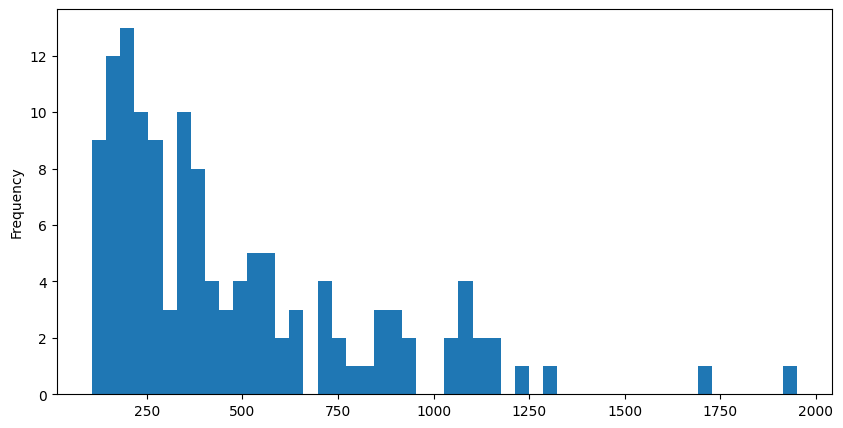

In [17]:
# lets plot and see the distribution of ratings given to books


final_ratings_50['number_of_ratings'].value_counts().sort_index().plot(kind='hist', bins=50, figsize=(10,5))


### Insights 
- From the above histogram for the rating distribution, it can e observed that distribution are positively skewed (righ-skewed)
(most observations are centered ay lower values and a long tail towards higher values)

In [18]:
stats_books = final_ratings.merge(average_rating, on = 'title')
stats_books.head(5)

,user_id,isbn,rating,title,author,year,publisher,image_url,number_of_ratings,mean,count
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82,82.0,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,7,7.0,7
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,1,1.0,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,1,1.0,1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,13,13.0,13


### Data Visualisation

#### As we filtered out the table(final_ratings_50) that had books with more than 50 ratings,now we will make a pivot table of that filtered table



## But first remove duplicate values


In [19]:
final_ratings = final_ratings.drop_duplicates(subset=['user_id', 'title'])

In [20]:
final_ratings.duplicated(subset=['user_id', 'title']).sum()

np.int64(0)

### Now we have no duplicate values inside ou final_ratings_50 df

In [ ]:
#using final_rating table for pivot table
#taking title in index as we are finding books for recommendation not users. Our research is not user-based.
pt = final_ratings_50.pivot_table(index='title', columns='user_id', values='rating').fillna(0)
pt.head()


user_id,254,2276,2766,2977,3363,3757,4017,4385,6242,6251,...,274004,274061,274301,274308,274808,275970,277427,277478,277639,278418
title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84 Charing Cross Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0


In [35]:
pt.shape

(742, 888)

### Converting PT to a sparce matrix:
- pivot table has many 0s

- sparse matrix stores mainly the non-zero values

- saves memory and makes nearest-neighbor similarity work better

In [30]:
from scipy.sparse import csr_matrix
pt_sparse = csr_matrix(pt.values)
pt_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15226 stored elements and shape (742, 888)>

### Model Training 

- for recommendation system , Nearest neighbour is the best model to work with (for finding most similar books)

In [31]:
from sklearn.neighbors import NearestNeighbors  # ths model help find similar books based on user ratings
model = NearestNeighbors(algorithm='brute')  # using brute-force algorithm to compute nearest neighbors
model.fit(pt_sparse)  # fiting the data to the model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Selecting a Book (for Recommendations)
- finding books in similar niche
- similar rating

In [ ]:
# iloc lets us find the info about a particular book , here book at index 237 (with ratings given by users)
pt.iloc[237]


user_id
254       9.0
2276      0.0
2766      0.0
2977      0.0
3363      0.0
         ... 
275970    9.0
277427    0.0
277478    0.0
277639    0.0
278418    0.0
Name: Harry Potter and the Chamber of Secrets (Book 2), Length: 888, dtype: float64

### Applying the model to find books with similar rating patterns

In [58]:
distance , suggestions = model.kneighbors(pt.iloc[238, :].values.reshape(1, -1), n_neighbors=6)
suggestions

array([[238, 240, 239, 237, 184, 536]])

In [59]:
for i in range(len(suggestions)):
    print(pt.index[suggestions[i]])

Index(['Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Order of the Phoenix (Book 5)',
       'Harry Potter and the Chamber of Secrets (Book 2)', 'Exclusive',
       'The Cradle Will Fall'],
      dtype='str', name='title')


### Insights 
- using KNN model, we were able to find the most similar 4 books to our selected book 'Harry Potter and the Chamber of Secrets (Book 2)' with respect to the rating given by users.

- here the key point is , we are not finding the books that are similar with respect to the content but with the ratings given by users




### Testing the model on a different book (from the returned list of similar books)

In [ ]:
# selecting a book with a similar title this time
distance , suggestions_2 = model.kneighbors(pt.iloc[184, :].values.reshape(1, -1), n_neighbors=6)
suggestions_2

array([[184, 536, 597, 291, 372, 187]])

In [98]:
for i in range(len(suggestions_2)):
    print(pt.index[suggestions_2[i]])

Index(['Exclusive', 'The Cradle Will Fall', 'The Long Road Home',
       'Jacob Have I Loved', 'No Safe Place', 'Eyes of a Child'],
      dtype='str', name='title')


In [100]:
# selecting a book with a different title this time

distance , suggestions_3 = model.kneighbors(pt.iloc[536, :].values.reshape(1, -1), n_neighbors=6)
suggestions_3


array([[536, 184, 372, 187, 597, 151]])

In [106]:
for i in range(len(suggestions_3)):
    print(pt.index[suggestions_3[i]])

Index(['The Cradle Will Fall', 'Exclusive', 'No Safe Place', 'Eyes of a Child',
       'The Long Road Home', 'Deck the Halls (Holiday Classics)'],
      dtype='str', name='title')


In [107]:
# checking similar or duplicate titles

pt.index[pt.index.str.contains('Harry Potter', case=False)]

Index(['Harry Potter and the Chamber of Secrets (Book 2)',
       'Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Order of the Phoenix (Book 5)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Sorcerer's Stone (Book 1)',
       'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'],
      dtype='str', name='title')

### Insights

- When testing the model on 'Harry Potter and the Chamber of Secrets (Book 2)', the recommended books were mostly other Harry Potter titles. This suggests the model is effectively capturing similarity in user rating patterns, especially for books belonging to the same series.


- Some recommendations overlapped across different input books, which suggests that certain books act as common nearest neighbors in the filtered dataset. This may be due to shared reader preferences, dataset sparsity, or highly popular books appearing similar to multiple titles.

- The model performs better for popular books with rich rating history, because collaborative filtering depends on overlapping user-rating behavior. For less popular books, recommendations may appear less meaningful due to sparse interactions.

### Final Insights from the Model Testing:

- The recommendation system was tested on both a similar-title book and a different-title book. For the Harry Potter title, the model recommended other Harry Potter books, showing that it captures strong similarity patterns among books in the same series.

- When tested on a different title, some overlap appeared in the recommendation list, suggesting that a few books act as common nearest neighbors in the dataset. Overall, the model shows that it can identify books with similar user rating behavior, though recommendations may be stronger for popular books with richer rating data.









#### Keeping the book titles inside variable 'book_title'

In [61]:
book_title = pt.index
book_title

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       '84 Charing Cross Road', 'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Cry In The Night',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='str', name='title', length=742)

In [108]:
# creating a function for recommendations

def recommend_books(book_title):
    book_index = np.where(pt.index == book_title)[0][0]
    distance , suggestions = model.kneighbors(pt.iloc[book_index, :].values.reshape(1, -1), n_neighbors=6)


    for i in range(len(suggestions)):
        print(pt.index[suggestions[i]])

In [ ]:
#calling the  & testing it on a random book
recommend_books("The Secret Garden")

Index(['The Secret Garden', 'Jacob Have I Loved', 'Exclusive',
       'Jewel (Oprah's Book Club)',
       'Vittorio the Vampire: New Tales of the Vampires', 'The Most Wanted'],
      dtype='str', name='title')


### Final Evaluation

- A recommendation function was created to return similar books for any given title.  

- The model performed well on popular and series-based books, showing that it can capture user-rating similarity patterns.  
Some overlap in recommendations was observed across different titles, which may be due to common reader preferences and sparse rating data.

In [ ]:
# first finding the ids of the book for which we want to find similar books using np.where
# [0][0] is used to get the first element of the array returned by np.where, 
# which is the index of the book in the final_ratings dataframe

# ids will only print the index of the book , for which the title given 
ids = np.where(final_ratings_50['title'] == 'Harry Potter and the Goblet of Fire (Book 4)')[0][0] 
ids


np.int64(338)

In [73]:
final_ratings_50.iloc[ids]['image_url']

'http://images.amazon.com/images/P/0439139597.01.LZZZZZZZ.jpg'